config

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

base = "/content/drive/MyDrive/IMS"
print("Exists:", os.path.exists(base))
print("Contents:", os.listdir(base))


Exists: True
Contents: ['1st_test.rar', 'Readme Document for IMS Bearing Data.pdf', '2nd_test.rar', '3rd_test.rar', '3rd_test', '2nd_test', '1st_test', 'bearing_rl_data.pkl', 'extracted', 'ims_labeled_features.csv', 'ims_features_all.csv']


In [ ]:
import os, glob

base = "/content/drive/MyDrive/IMS/extracted"
candidates = [d for d in glob.glob(os.path.join(base, "1st_test", "**"), recursive=True) if os.path.isdir(d)]
# pick the deepest folder that actually has files
DIR1 = None
for d in sorted(candidates, key=lambda x: x.count(os.sep), reverse=True):
    files = [p for p in glob.glob(os.path.join(d, "*")) if os.path.isfile(p)]
    if len(files) > 100:  # IMS 1st_test has 2156 files
        DIR1 = d
        break

print("DIR1:", DIR1)
if DIR1:
    sample = [p for p in glob.glob(os.path.join(DIR1, "*")) if os.path.isfile(p)][:3]
    print("Sample files:", sample)


DIR1: /content/drive/MyDrive/IMS/extracted/1st_test/1st_test
Sample files: ['/content/drive/MyDrive/IMS/extracted/1st_test/1st_test/2003.11.16.01.08.46', '/content/drive/MyDrive/IMS/extracted/1st_test/1st_test/2003.11.16.00.58.46', '/content/drive/MyDrive/IMS/extracted/1st_test/1st_test/2003.11.16.01.28.46']


Feauture functions

In [ ]:
import numpy as np
from scipy.stats import kurtosis
from scipy.signal import butter, filtfilt, hilbert, welch

FS = 20000
NYQ = FS/2

def _butter_band(x, low, high):
    low = max(1e-6, low/NYQ); high = min(0.999, high/NYQ)
    b,a = butter(4, [low, high], btype="band")
    return filtfilt(b,a,x)

def _band_energy_welch(x, a, b):
    f, Pxx = welch(x, fs=FS, nperseg=1024)
    m = (f>=a) & (f<b)
    return float(Pxx[m].sum())

def extract_features(sig):
    x = sig[:,0] if sig.ndim==2 else sig
    x = x.astype(np.float32)
    rms = float(np.sqrt(np.mean(x**2)))
    mean = float(np.mean(x))
    std = float(np.std(x))
    ptp = float(x.max()-x.min())
    crest = float((np.max(np.abs(x)) / (rms+1e-12)))
    mad = float(np.mean(np.abs(x-mean)))
    kur = float(kurtosis(x, fisher=True))
    x_hp = _butter_band(x, 3000, 9500)
    e48 = _band_energy_welch(x_hp, 4000, 8000)
    e89 = _band_energy_welch(x_hp, 8000, 9500)
    x_env = np.abs(hilbert(_butter_band(x, 4000, 9000)))
    env_rms = float(np.sqrt(np.mean(x_env**2)))
    env_kur = float(kurtosis(x_env, fisher=True))
    return np.array([rms, std, mad, ptp, crest, kur, e48, e89, env_rms, env_kur], dtype=np.float32)


In [ ]:
import numpy as np, pandas as pd, glob

XCOLS = ["rms","std","mad","ptp","crest","kurtosis","band_4_8k","band_8_9k5","env_rms","env_kurtosis"]

def load_dir(dirpath, extract_features):
    files = sorted([p for p in glob.glob(os.path.join(dirpath, "*")) if os.path.isfile(p)])
    rows = []
    for i, f in enumerate(files):
        sig = np.loadtxt(f)
        feat = extract_features(sig)
        rows.append(dict(zip(XCOLS, feat)) | {"file_index": i, "path": f, "set": "1st_test"})
    return pd.DataFrame(rows)

df1 = load_dir(DIR1, extract_features)
print(df1.shape)
print(df1.columns)
print(df1.head(3))


(2156, 13)
Index(['rms', 'std', 'mad', 'ptp', 'crest', 'kurtosis', 'band_4_8k',
       'band_8_9k5', 'env_rms', 'env_kurtosis', 'file_index', 'path', 'set'],
      dtype='object')
        rms       std       mad    ptp     crest  kurtosis  band_4_8k  \
0  0.124614  0.081122  0.063496  1.108  5.777851  1.069163   0.000105   
1  0.123811  0.079515  0.062070  1.042  5.282237  1.161551   0.000099   
2  0.125246  0.080217  0.062838  0.940  4.974196  0.986286   0.000102   

   band_8_9k5   env_rms  env_kurtosis  file_index  \
0    0.000008  0.060285      4.189158           0   
1    0.000008  0.059273      5.287453           1   
2    0.000008  0.059922      5.335374           2   

                                                path       set  
0  /content/drive/MyDrive/IMS/extracted/1st_test/...  1st_test  
1  /content/drive/MyDrive/IMS/extracted/1st_test/...  1st_test  
2  /content/drive/MyDrive/IMS/extracted/1st_test/...  1st_test  


In [ ]:
df1["label_bin"]    = np.where(df1.file_index < 300,  "healthy",  "fault")
df1["label_stage2"] = np.where(df1.file_index < 1800, "degraded", "failing")

df1[["file_index","label_bin","label_stage2"]].head()


,file_index,label_bin,label_stage2
0,0,healthy,degraded
1,1,healthy,degraded
2,2,healthy,degraded
3,3,healthy,degraded
4,4,healthy,degraded


Train Stage-1 and Stage-2, save models

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import joblib, os

XCOLS = ["rms","std","mad","ptp","crest","kurtosis","band_4_8k","band_8_9k5","env_rms","env_kurtosis"]
MODEL_DIR = "/content/drive/MyDrive/IMS/models"
os.makedirs(MODEL_DIR, exist_ok=True)

# Stage-1 (healthy vs fault) – SVM
split1 = 1800
X_tr = df1.loc[:split1-1, XCOLS].values
y_tr = df1.loc[:split1-1, "label_bin"].values
X_te = df1.loc[split1:, XCOLS].values
y_te = df1.loc[split1:, "label_bin"].values

stage1 = make_pipeline(StandardScaler(), SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42))
stage1.fit(X_tr, y_tr)
print("Stage-1 report:\n", classification_report(y_te, stage1.predict(X_te), digits=3, zero_division=0))

# Stage-2 (degraded vs failing) – Logistic Regression
g_tr = df1[(df1.file_index>=300) & (df1.file_index<2000)]
g_te = df1[(df1.file_index>=2000)]
stage2 = make_pipeline(StandardScaler(), LogisticRegression(max_iter=600, class_weight="balanced", random_state=42))
stage2.fit(g_tr[XCOLS].values, g_tr["label_stage2"].values)
print("Stage-2 report:\n", classification_report(g_te["label_stage2"].values, stage2.predict(g_te[XCOLS].values), digits=3, zero_division=0))

joblib.dump(stage1, f"{MODEL_DIR}/stage1_svm.pkl")
joblib.dump(stage2, f"{MODEL_DIR}/stage2_logreg.pkl")
print("Saved models to:", MODEL_DIR)


Stage-1 report:
               precision    recall  f1-score   support

       fault      1.000     1.000     1.000       356

    accuracy                          1.000       356
   macro avg      1.000     1.000     1.000       356
weighted avg      1.000     1.000     1.000       356

Stage-2 report:
               precision    recall  f1-score   support

    degraded      0.000     0.000     0.000         0
     failing      1.000     0.994     0.997       156

    accuracy                          0.994       156
   macro avg      0.500     0.497     0.498       156
weighted avg      1.000     0.994     0.997       156

Saved models to: /content/drive/MyDrive/IMS/models


realtime stream simulator

In [ ]:
import glob, time, numpy as np, pandas as pd, joblib, os

ROOT = "/content/drive/MyDrive/IMS/extracted"
SET_FOR_STREAM = "1st_test"   # change to "2nd_test"/"3rd_test" if you want

stage1 = joblib.load(f"{MODEL_DIR}/stage1_svm.pkl")
stage2 = joblib.load(f"{MODEL_DIR}/stage2_logreg.pkl")

def list_stream_files(set_name=SET_FOR_STREAM):
    return sorted([p for p in glob.glob(os.path.join(ROOT, set_name, "**", "*"), recursive=True) if os.path.isfile(p)])

def realtime_detect(files, k_consec=3, prob_thresh=0.5, sleep_sec=0.0):
    log = []
    consec = 0
    for i, f in enumerate(files):
        sig = np.loadtxt(f)
        feat = extract_features(sig).reshape(1, -1)
        p_fault = stage1.predict_proba(feat)[0][list(stage1.classes_).index("fault")]
        pred_fault = int(p_fault >= prob_thresh)
        consec = consec + 1 if pred_fault else 0
        alarm = int(consec >= k_consec)
        grade = stage2.predict(feat)[0] if alarm else ""
        log.append({"i": i, "file": os.path.basename(f), "p_fault": float(p_fault), "pred_fault": pred_fault, "alarm": alarm, "grade": grade})
        if sleep_sec: time.sleep(sleep_sec)
    return pd.DataFrame(log)

# stream a later slice so you see alarms
files = list_stream_files("1st_test")[1700:2156]
df_log = realtime_detect(files, k_consec=3, prob_thresh=0.5, sleep_sec=0.0)
df_log.head(), df_log.tail()


(   i                 file   p_fault  pred_fault  alarm     grade
 0  0  2003.11.21.18.26.56  0.999805           1      0          
 1  1  2003.11.21.18.36.56  0.999936           1      0          
 2  2  2003.11.21.18.46.56  0.999555           1      1  degraded
 3  3  2003.11.21.18.56.56  0.988162           1      1  degraded
 4  4  2003.11.21.19.06.56  0.992311           1      1   failing,
        i                 file   p_fault  pred_fault  alarm    grade
 451  451  2003.11.25.16.07.32  0.910048           1      1  failing
 452  452  2003.11.25.23.13.21  0.903461           1      1  failing
 453  453  2003.11.25.23.19.56  0.903481           1      1  failing
 454  454  2003.11.25.23.29.56  0.903532           1      1  failing
 455  455  2003.11.25.23.39.56  0.903503           1      1  failing)

save logs

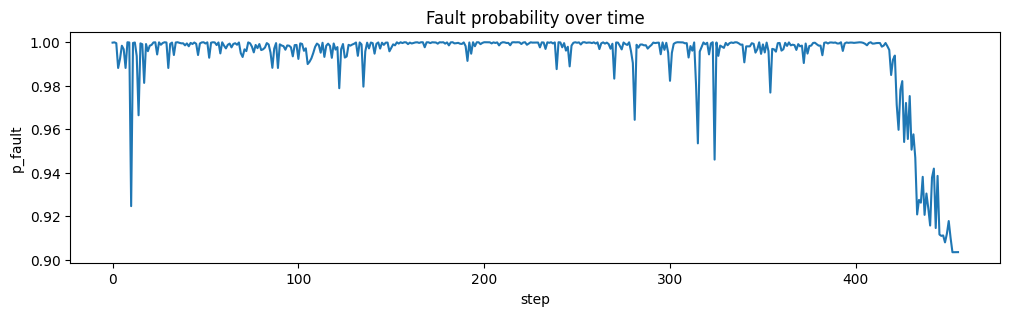

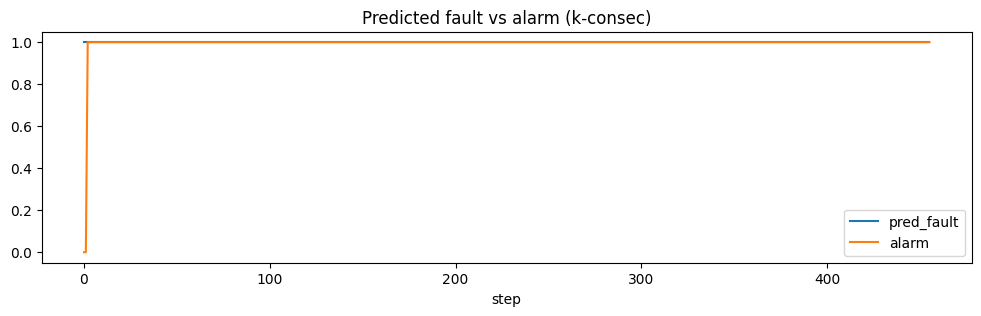

Saved: /content/drive/MyDrive/IMS/realtime_log.csv


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,3))
plt.plot(df_log["i"], df_log["p_fault"])
plt.title("Fault probability over time"); plt.xlabel("step"); plt.ylabel("p_fault"); plt.show()

plt.figure(figsize=(12,3))
plt.plot(df_log["i"], df_log["pred_fault"], label="pred_fault")
plt.plot(df_log["i"], df_log["alarm"], label="alarm")
plt.legend(); plt.title("Predicted fault vs alarm (k-consec)"); plt.xlabel("step"); plt.show()

out_csv = "/content/drive/MyDrive/IMS/realtime_log.csv"
df_log.to_csv(out_csv, index=False)
print("Saved:", out_csv)


In [ ]:
# path to save
log_path = "/content/drive/MyDrive/IMS/realtime_log_1st_test.csv"

df_log.to_csv(log_path, index=False)
print("✅ Log saved to:", log_path)
print(df_log.head())


✅ Log saved to: /content/drive/MyDrive/IMS/realtime_log_1st_test.csv
   i                 file   p_fault  pred_fault  alarm     grade
0  0  2003.11.21.18.26.56  0.999805           1      0          
1  1  2003.11.21.18.36.56  0.999936           1      0          
2  2  2003.11.21.18.46.56  0.999555           1      1  degraded
3  3  2003.11.21.18.56.56  0.988162           1      1  degraded
4  4  2003.11.21.19.06.56  0.992311           1      1   failing


In [ ]:
summary = {}

# First alarm
first_alarm = df_log.index[df_log["alarm"] == 1][0]
summary["First alarm index"] = int(first_alarm)

# File name
summary["First alarm file"] = df_log.loc[first_alarm, "file"]

# Grade at first alarm
summary["First alarm grade"] = df_log.loc[first_alarm, "grade"]

# Final step
summary["Total streamed samples"] = int(df_log.shape[0])

# Lead in samples
summary["Lead (samples before end)"] = int(df_log.shape[0] - first_alarm)

import pandas as pd
summary_df = pd.DataFrame.from_dict(summary, orient='index', columns=["value"])
print(summary_df)


                                         value
First alarm index                            2
First alarm file           2003.11.21.18.46.56
First alarm grade                     degraded
Total streamed samples                     456
Lead (samples before end)                  454
